# Deep Learning Project - Image Segmentation

### **Name:** Yara Hatem  
### **ID:** 236125  

# **Preprocessing**

In [1]:
import os
import glob
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
import random

## Label Mapping

In [2]:
def get_cityscapes_mapping():
    mapping = np.full(256, 255, dtype=np.int64)  # default = ignore
    mapping[7]  = 0   # road
    mapping[8]  = 1   # sidewalk
    mapping[11] = 2   # building
    mapping[12] = 3   # wall
    mapping[13] = 4   # fence
    mapping[17] = 5   # pole
    mapping[19] = 6   # traffic light
    mapping[20] = 7   # traffic sign
    mapping[21] = 8   # vegetation
    mapping[22] = 9   # terrain
    mapping[23] = 10  # sky
    mapping[24] = 11  # person
    mapping[25] = 12  # rider
    mapping[26] = 13  # car
    mapping[27] = 14  # truck
    mapping[28] = 15  # bus
    mapping[31] = 16  # train
    mapping[32] = 17  # motorcycle
    mapping[33] = 18  # bicycle
    return mapping

In [3]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

## Dataset Class
The `CityscapesDataset` class loads image-mask pairs from the Cityscapes dataset. For each sample, it applies the following steps:
- **File loading:** Uses `glob` to collect all image and mask paths from the dataset directory
- **Random resize:** Scales the image between 75% and 150% of its original size
- **Random horizontal flip:** 50% chance of flipping the image left-right
- **Crop safety check:** Ensures the image is at least `crop_size` before cropping
- **Random crop:** Crops a fixed `512×512` patch from the image and mask
- **Normalization:** Normalizes pixel values using ImageNet mean and std
- **Label mapping:** Converts raw Cityscapes label IDs to 19 training classes

In [4]:
class CityscapesDataset(Dataset):
    def __init__(self, root, split='train', crop_size=512):
        self.split     = split
        self.crop_size = crop_size
        self.mapping   = get_cityscapes_mapping()

        img_dir  = os.path.join(root, 'leftImg8bit', split)
        mask_dir = os.path.join(root, 'gtFine', split)

        # Use glob for clean file loading (her approach)
        self.images = sorted(glob.glob(os.path.join(img_dir,  '*', '*_leftImg8bit.png')))
        self.masks  = sorted(glob.glob(os.path.join(mask_dir, '*', '*_gtFine_labelIds.png')))

        print(f"[{split}] Found {len(self.images)} image-mask pairs.")

    def __len__(self):
        return len(self.images)

    def transform(self, image, mask):
        if self.split == 'train':
            # Random resize
            scale = random.uniform(0.75, 1.5)  # was 0.5, 2.0
            new_w = int(image.width  * scale)
            new_h = int(image.height * scale)
            image = TF.resize(image, (new_h, new_w), Image.BILINEAR)
            mask  = TF.resize(mask,  (new_h, new_w), Image.NEAREST)

            # Random horizontal flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask  = TF.hflip(mask)

            # Add this before the crop block
            if image.width < self.crop_size or image.height < self.crop_size:
                image = TF.resize(image, (self.crop_size, self.crop_size), Image.BILINEAR)
                mask  = TF.resize(mask,  (self.crop_size, self.crop_size), Image.NEAREST)
    
            # Random crop
            i, j, h, w = transforms.RandomCrop.get_params(
                image, output_size=(self.crop_size, self.crop_size)
            )
            image = TF.crop(image, i, j, h, w)
            mask  = TF.crop(mask,  i, j, h, w)

        else:
            # Val/Test: just resize
            image = TF.resize(image, (self.crop_size, self.crop_size), Image.BILINEAR)
            mask  = TF.resize(mask,  (self.crop_size, self.crop_size), Image.NEAREST)

        # Normalize image
        image = TF.to_tensor(image)
        image = TF.normalize(image,
                             mean=[0.485, 0.456, 0.406],
                             std= [0.229, 0.224, 0.225])

        # Apply label mapping (her faster numpy approach)
        mask = np.array(mask, dtype=np.int64)
        mask = self.mapping[mask]
        mask = torch.from_numpy(mask).long()

        return image, mask

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        mask  = Image.open(self.masks[idx])
        return self.transform(image, mask)

## Data Loaders

In [5]:
ROOT = '/kaggle/input/datasets/kavithak1388/cityscapes/Cityscape'

train_dataset = CityscapesDataset(ROOT, split='train', crop_size=512)
val_dataset   = CityscapesDataset(ROOT, split='val',   crop_size=512)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

[train] Found 2975 image-mask pairs.
[val] Found 500 image-mask pairs.


## Sanity Check

In [6]:
img, mask = next(iter(train_loader))
print("Image shape :", img.shape)        # [4, 3, 512, 512]
print("Mask shape  :", mask.shape)       # [4, 512, 512]
print("Unique labels:", torch.unique(mask))  # 0-18 + 255

Image shape : torch.Size([8, 3, 512, 512])
Mask shape  : torch.Size([8, 512, 512])
Unique labels: tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         15,  17,  18, 255])


## Visualization (Image & Mask Sample)

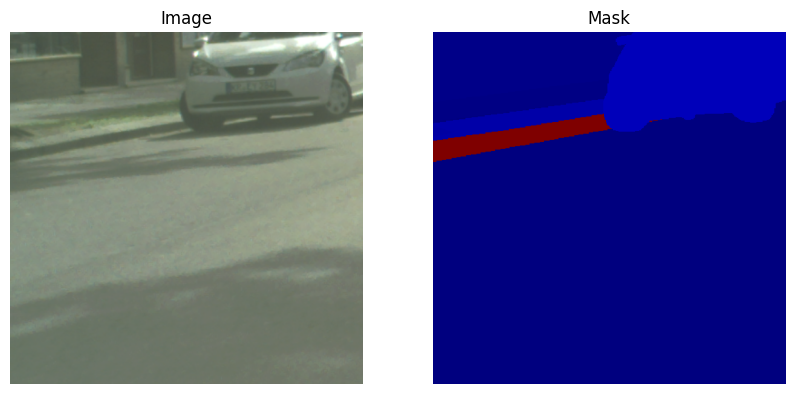

In [10]:
import matplotlib.pyplot as plt

img, mask = next(iter(train_loader))

# Denormalize image for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_display = img[0].cpu() * std + mean
img_display = img_display.permute(1, 2, 0).clamp(0, 1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_display)
plt.title("Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask[0].cpu(), cmap='jet')
plt.title("Mask")
plt.axis('off')

plt.show()

# **Evaluation Metrics**

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [9]:
import time

def compute_miou(preds, labels, num_classes=19, ignore_index=255):
    iou_list = []
    preds = preds.argmax(dim=1)
    for cls in range(num_classes):
        pred_mask  = (preds == cls)
        label_mask = (labels == cls)
        ignore     = (labels == ignore_index)
        pred_mask  = pred_mask & ~ignore
        label_mask = label_mask & ~ignore
        intersection = (pred_mask & label_mask).sum().item()
        union        = (pred_mask | label_mask).sum().item()
        if union == 0:
            continue
        iou_list.append(intersection / union)
    return sum(iou_list) / len(iou_list) if iou_list else 0.0

def compute_pixel_accuracy(preds, labels, ignore_index=255):
    preds   = preds.argmax(dim=1)
    valid   = labels != ignore_index
    correct = ((preds == labels) & valid).sum().item()
    total   = valid.sum().item()
    return correct / total if total > 0 else 0.0

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_inference_time(model, device, input_size=(1, 3, 512, 512), runs=20):
    model.eval()
    dummy = torch.randn(*input_size).to(device)
    with torch.no_grad():
        for _ in range(5):
            _ = model(dummy)
    start = time.time()
    with torch.no_grad():
        for _ in range(runs):
            _ = model(dummy)
    return (time.time() - start) / runs

# **Models** 

# **FCN Baseline**

In [12]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

In [13]:
class FCN(nn.Module):
    def __init__(self, num_classes=19):
        super(FCN, self).__init__()

        # Backbone: ResNet50 pretrained
        backbone = models.resnet50(pretrained=True)

        # Encoder (keep all layers except avgpool and fc)
        self.encoder1 = nn.Sequential(*list(backbone.children())[:5])  # output: /4
        self.encoder2 = backbone.layer2  # output: /8
        self.encoder3 = backbone.layer3  # output: /16
        self.encoder4 = backbone.layer4  # output: /32

        # FCN Head: 1x1 conv to num_classes
        self.classifier = nn.Conv2d(2048, num_classes, kernel_size=1)

        # Upsample back to input size
        self.upsample = nn.Upsample(scale_factor=32, mode='bilinear', align_corners=True)

    def forward(self, x):
        x = self.encoder1(x)
        x = self.encoder2(x)
        x = self.encoder3(x)
        x = self.encoder4(x)
        x = self.classifier(x)
        x = self.upsample(x)
        return x

In [14]:
model = FCN(num_classes=19).to(device)

# Test with a dummy input
dummy = torch.randn(2, 3, 512, 512).to(device)
output = model(dummy)
print(f"Input shape  : {dummy.shape}")   # [2, 3, 512, 512]
print(f"Output shape : {output.shape}")  # [2, 19, 512, 512]

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Input shape  : torch.Size([2, 3, 512, 512])
Output shape : torch.Size([2, 19, 512, 512])


## Loss, Optimizer & Scheduler

In [12]:
criterion = nn.CrossEntropyLoss(ignore_index=255)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.PolynomialLR(optimizer, total_iters=50, power=0.9)

## Training Loop

In [14]:
NUM_EPOCHS = 20
best_miou  = 0.0
best_pixel_acc = 0.0

print(f"FCN Parameters: {count_parameters(model):,}")
print("-" * 70)

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # ── Training ──────────────────────────────
    model.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    scheduler.step()
    train_loss /= len(train_loader)
    epoch_time  = time.time() - epoch_start

    # ── Validation ────────────────────────────
    model.eval()
    val_loss      = 0.0
    val_miou      = 0.0
    val_pixel_acc = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)

            outputs        = model(imgs)
            loss           = criterion(outputs, masks)
            val_loss      += loss.item()
            val_miou      += compute_miou(outputs, masks)
            val_pixel_acc += compute_pixel_accuracy(outputs, masks)

    val_loss      /= len(val_loader)
    val_miou      /= len(val_loader)
    val_pixel_acc /= len(val_loader)

    # ── Save best model ───────────────────────
    if val_miou > best_miou:
        best_miou      = val_miou
        best_pixel_acc = val_pixel_acc
        torch.save(model.state_dict(), 'fcn_best.pth')
        print(f"  ✅ Best model saved! mIoU: {best_miou:.4f}")

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"mIoU: {val_miou:.4f} | "
          f"Pixel Acc: {val_pixel_acc:.4f} | "
          f"Time: {epoch_time:.1f}s")

FCN Parameters: 23,546,963
----------------------------------------------------------------------
  ✅ Best model saved! mIoU: 0.3368
Epoch [01/20] Train Loss: 0.3761 | Val Loss: 0.4326 | mIoU: 0.3368 | Pixel Acc: 0.8572 | Time: 251.5s
Epoch [02/20] Train Loss: 0.3406 | Val Loss: 0.4591 | mIoU: 0.3259 | Pixel Acc: 0.8519 | Time: 249.7s
  ✅ Best model saved! mIoU: 0.3373
Epoch [03/20] Train Loss: 0.3330 | Val Loss: 0.4164 | mIoU: 0.3373 | Pixel Acc: 0.8641 | Time: 252.3s
Epoch [04/20] Train Loss: 0.3438 | Val Loss: 0.4668 | mIoU: 0.3361 | Pixel Acc: 0.8510 | Time: 251.4s
  ✅ Best model saved! mIoU: 0.3411
Epoch [05/20] Train Loss: 0.3206 | Val Loss: 0.4317 | mIoU: 0.3411 | Pixel Acc: 0.8576 | Time: 250.3s
Epoch [06/20] Train Loss: 0.3252 | Val Loss: 0.4744 | mIoU: 0.3305 | Pixel Acc: 0.8497 | Time: 253.7s
  ✅ Best model saved! mIoU: 0.3527
Epoch [07/20] Train Loss: 0.3111 | Val Loss: 0.4191 | mIoU: 0.3527 | Pixel Acc: 0.8592 | Time: 250.8s
Epoch [08/20] Train Loss: 0.2930 | Val Loss: 0.4

## Save FCN Baseline Results

In [15]:
fcn_inference_time = compute_inference_time(model, device)
fcn_params         = count_parameters(model)

fcn_results = {
    'Model'          : 'FCN (Baseline)',
    'mIoU'           : round(best_miou, 4),
    'Pixel Accuracy' : round(best_pixel_acc, 4),
    'Parameters'     : f"{fcn_params:,}",
    'Inference Time' : f"{fcn_inference_time:.4f}s"
}

print(fcn_results)

{'Model': 'FCN (Baseline)', 'mIoU': 0.387, 'Pixel Accuracy': 0.8792, 'Parameters': '23,546,963', 'Inference Time': '0.0188s'}


# **SegFormer**

In [13]:
!pip install transformers -q

## Import & Load SegFormer

In [14]:
from transformers import SegformerForSemanticSegmentation
import torch.nn.functional as F

segformer_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=19,
    ignore_mismatched_sizes=True
).to(device)

print("SegFormer loaded!")
print(f"Parameters: {count_parameters(segformer_model):,}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

SegFormer loaded!
Parameters: 3,719,027


model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

## Loss & Optimizer

In [19]:
criterion_seg = nn.CrossEntropyLoss(ignore_index=255)
optimizer_seg = torch.optim.Adam(segformer_model.parameters(), lr=6e-5)
scheduler_seg = torch.optim.lr_scheduler.PolynomialLR(optimizer_seg, total_iters=20, power=0.9)

## Training Loop

In [21]:
NUM_EPOCHS_SEG = 20
best_miou_seg  = 0.0
best_pixel_acc_seg = 0.0

for epoch in range(NUM_EPOCHS_SEG):
    epoch_start = time.time()

    # ── Training ──────────────────────────────
    segformer_model.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        optimizer_seg.zero_grad()
        outputs = segformer_model(pixel_values=imgs, labels=masks)
        loss    = outputs.loss
        loss.backward()
        optimizer_seg.step()

        train_loss += loss.item()

    scheduler_seg.step()
    train_loss /= len(train_loader)
    epoch_time  = time.time() - epoch_start

    # ── Validation ────────────────────────────
    segformer_model.eval()
    val_loss      = 0.0
    val_miou      = 0.0
    val_pixel_acc = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)

            outputs = segformer_model(pixel_values=imgs, labels=masks)
            loss    = outputs.loss
            logits  = outputs.logits  # [B, 19, H/4, W/4]

            # Upsample to original mask size
            upsampled = F.interpolate(logits, size=masks.shape[-2:],
                                      mode='bilinear', align_corners=False)

            val_loss      += loss.item()
            val_miou      += compute_miou(upsampled, masks)
            val_pixel_acc += compute_pixel_accuracy(upsampled, masks)

    val_loss      /= len(val_loader)
    val_miou      /= len(val_loader)
    val_pixel_acc /= len(val_loader)

    # ── Save best model ───────────────────────
    if val_miou > best_miou_seg:
        best_miou_seg      = val_miou
        best_pixel_acc_seg = val_pixel_acc
        torch.save(segformer_model.state_dict(), 'segformer_best.pth')
        print(f"  ✅ Best model saved! mIoU: {best_miou_seg:.4f}")

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS_SEG}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"mIoU: {val_miou:.4f} | "
          f"Pixel Acc: {val_pixel_acc:.4f} | "
          f"Time: {epoch_time:.1f}s")

  ✅ Best model saved! mIoU: 0.2789
Epoch [01/20] Train Loss: 0.7143 | Val Loss: 0.5958 | mIoU: 0.2789 | Pixel Acc: 0.8458 | Time: 238.2s
  ✅ Best model saved! mIoU: 0.3091
Epoch [02/20] Train Loss: 0.5293 | Val Loss: 0.5010 | mIoU: 0.3091 | Pixel Acc: 0.8578 | Time: 242.3s
  ✅ Best model saved! mIoU: 0.3223
Epoch [03/20] Train Loss: 0.4440 | Val Loss: 0.4674 | mIoU: 0.3223 | Pixel Acc: 0.8605 | Time: 237.4s
  ✅ Best model saved! mIoU: 0.3384
Epoch [04/20] Train Loss: 0.4020 | Val Loss: 0.4454 | mIoU: 0.3384 | Pixel Acc: 0.8644 | Time: 239.0s
  ✅ Best model saved! mIoU: 0.3453
Epoch [05/20] Train Loss: 0.3770 | Val Loss: 0.4300 | mIoU: 0.3453 | Pixel Acc: 0.8694 | Time: 238.8s
  ✅ Best model saved! mIoU: 0.3554
Epoch [06/20] Train Loss: 0.3523 | Val Loss: 0.4059 | mIoU: 0.3554 | Pixel Acc: 0.8756 | Time: 233.0s
Epoch [07/20] Train Loss: 0.3290 | Val Loss: 0.4042 | mIoU: 0.3477 | Pixel Acc: 0.8742 | Time: 236.5s
  ✅ Best model saved! mIoU: 0.3662
Epoch [08/20] Train Loss: 0.3153 | Val Lo

## Save SegFormer Results

In [23]:
segformer_inference_time = compute_inference_time(segformer_model, device)
segformer_params         = count_parameters(segformer_model)

segformer_results = {
    'Model'          : 'SegFormer (MiT-B0)',
    'mIoU'           : round(best_miou_seg, 4),
    'Pixel Accuracy' : round(best_pixel_acc_seg, 4),
    'Parameters'     : f"{segformer_params:,}",
    'Inference Time' : f"{segformer_inference_time:.4f}s"
}

print(segformer_results)

{'Model': 'SegFormer (MiT-B0)', 'mIoU': 0.3962, 'Pixel Accuracy': 0.8972, 'Parameters': '3,719,027', 'Inference Time': '0.0163s'}


# **TransFuse**

## TransFuse Model

In [25]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
from transformers import ViTModel

class BiFusion(nn.Module):
    def __init__(self, channels):
        super(BiFusion, self).__init__()
        self.channel_att = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // 4),
            nn.ReLU(),
            nn.Linear(channels // 4, channels),
            nn.Sigmoid()
        )
        self.spatial_att = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=7, padding=3),
            nn.Sigmoid()
        )
        self.residual = nn.Conv2d(channels * 2, channels, kernel_size=1)

    def forward(self, cnn_feat, trans_feat):
        # Channel attention
        ch_att  = self.channel_att(cnn_feat).unsqueeze(-1).unsqueeze(-1)
        cnn_att = cnn_feat * ch_att

        # Spatial attention
        avg_out = torch.mean(trans_feat, dim=1, keepdim=True)
        max_out = torch.max(trans_feat, dim=1, keepdim=True)[0]
        sp_att  = self.spatial_att(torch.cat([avg_out, max_out], dim=1))
        trans_att = trans_feat * sp_att

        # Fusion
        fused = torch.cat([cnn_att, trans_att], dim=1)
        fused = self.residual(fused)
        return fused


class TransFuse(nn.Module):
    def __init__(self, num_classes=19):
        super(TransFuse, self).__init__()

        # CNN Branch (ResNet50)
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.cnn_encoder = nn.Sequential(*list(resnet.children())[:-2])  # [B, 2048, 16, 16]
        self.cnn_proj    = nn.Conv2d(2048, 256, kernel_size=1)

        # Transformer Branch (ViT)
        self.vit      = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')
        self.vit_proj = nn.Conv2d(768, 256, kernel_size=1)

        # BiFusion
        self.bifusion = BiFusion(channels=256)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, num_classes, kernel_size=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape

        # CNN Branch
        cnn_feat = self.cnn_encoder(x)          # [B, 2048, 16, 16]
        cnn_feat = self.cnn_proj(cnn_feat)       # [B, 256, 16, 16]

        # Transformer Branch
        x_resized  = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        vit_out    = self.vit(pixel_values=x_resized).last_hidden_state  # [B, 197, 768]
        vit_tokens = vit_out[:, 1:, :]                                   # remove CLS [B, 196, 768]
        vit_feat   = vit_tokens.permute(0, 2, 1).reshape(B, 768, 14, 14) # [B, 768, 14, 14]
        vit_feat   = self.vit_proj(vit_feat)                              # [B, 256, 14, 14]
        vit_feat   = F.interpolate(vit_feat, size=cnn_feat.shape[-2:],
                                   mode='bilinear', align_corners=False)  # [B, 256, 16, 16]

        # BiFusion
        fused = self.bifusion(cnn_feat, vit_feat)  # [B, 256, 16, 16]

        # Decode
        out = self.decoder(fused)                  # [B, 19, 16, 16]
        out = F.interpolate(out, size=(H, W),
                            mode='bilinear', align_corners=False)  # [B, 19, H, W]
        return out

## Load Model

In [21]:
transfuse_model = TransFuse(num_classes=19).to(device)
print("TransFuse loaded!")
print(f"Parameters: {count_parameters(transfuse_model):,}")

# Quick sanity check
dummy = torch.randn(2, 3, 512, 512).to(device)
out   = transfuse_model(dummy)
print(f"Output shape: {out.shape}")  # [2, 19, 512, 512]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

TransFuse loaded!
Parameters: 111,080,950
Output shape: torch.Size([2, 19, 512, 512])


## Loss & Optimizer

In [23]:
criterion_tf = nn.CrossEntropyLoss(ignore_index=255)
optimizer_tf = torch.optim.Adam(transfuse_model.parameters(), lr=1e-4)
scheduler_tf = torch.optim.lr_scheduler.PolynomialLR(optimizer_tf, total_iters=20, power=0.9)

## Training Loop

In [24]:
NUM_EPOCHS_TF = 20
best_miou_tf  = 0.0
best_pixel_acc_tf = 0.0

for epoch in range(NUM_EPOCHS_TF):
    epoch_start = time.time()

    # ── Training ──────────────────────────────
    transfuse_model.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        optimizer_tf.zero_grad()
        outputs = transfuse_model(imgs)
        loss    = criterion_tf(outputs, masks)
        loss.backward()
        optimizer_tf.step()

        train_loss += loss.item()

    scheduler_tf.step()
    train_loss /= len(train_loader)
    epoch_time  = time.time() - epoch_start

    # ── Validation ────────────────────────────
    transfuse_model.eval()
    val_loss      = 0.0
    val_miou      = 0.0
    val_pixel_acc = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)

            outputs        = transfuse_model(imgs)
            loss           = criterion_tf(outputs, masks)
            val_loss      += loss.item()
            val_miou      += compute_miou(outputs, masks)
            val_pixel_acc += compute_pixel_accuracy(outputs, masks)

    val_loss      /= len(val_loader)
    val_miou      /= len(val_loader)
    val_pixel_acc /= len(val_loader)

    # ── Save best model ───────────────────────
    if val_miou > best_miou_tf:
        best_miou_tf      = val_miou
        best_pixel_acc_tf = val_pixel_acc
        torch.save(transfuse_model.state_dict(), 'transfuse_best.pth')
        print(f"  ✅ Best model saved! mIoU: {best_miou_tf:.4f}")

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS_TF}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"mIoU: {val_miou:.4f} | "
          f"Pixel Acc: {val_pixel_acc:.4f} | "
          f"Time: {epoch_time:.1f}s")

  ✅ Best model saved! mIoU: 0.2767
Epoch [01/20] Train Loss: 0.8486 | Val Loss: 0.6821 | mIoU: 0.2767 | Pixel Acc: 0.8326 | Time: 331.6s
  ✅ Best model saved! mIoU: 0.3087
Epoch [02/20] Train Loss: 0.4838 | Val Loss: 0.5039 | mIoU: 0.3087 | Pixel Acc: 0.8553 | Time: 327.3s
  ✅ Best model saved! mIoU: 0.3124
Epoch [03/20] Train Loss: 0.4009 | Val Loss: 0.4796 | mIoU: 0.3124 | Pixel Acc: 0.8563 | Time: 327.9s
  ✅ Best model saved! mIoU: 0.3465
Epoch [04/20] Train Loss: 0.3351 | Val Loss: 0.4437 | mIoU: 0.3465 | Pixel Acc: 0.8678 | Time: 327.6s
  ✅ Best model saved! mIoU: 0.3543
Epoch [05/20] Train Loss: 0.3114 | Val Loss: 0.4153 | mIoU: 0.3543 | Pixel Acc: 0.8712 | Time: 327.4s
Epoch [06/20] Train Loss: 0.3141 | Val Loss: 0.4376 | mIoU: 0.3432 | Pixel Acc: 0.8637 | Time: 327.4s
  ✅ Best model saved! mIoU: 0.3765
Epoch [07/20] Train Loss: 0.2824 | Val Loss: 0.3918 | mIoU: 0.3765 | Pixel Acc: 0.8776 | Time: 327.1s
Epoch [08/20] Train Loss: 0.2685 | Val Loss: 0.3880 | mIoU: 0.3724 | Pixel A

## Save TransFuse Results

In [25]:
transfuse_inference_time = compute_inference_time(transfuse_model, device)
transfuse_params         = count_parameters(transfuse_model)

transfuse_results = {
    'Model'          : 'TransFuse',
    'mIoU'           : round(best_miou_tf, 4),
    'Pixel Accuracy' : round(best_pixel_acc_tf, 4),
    'Parameters'     : f"{transfuse_params:,}",
    'Inference Time' : f"{transfuse_inference_time:.4f}s"
}

print(transfuse_results)

{'Model': 'TransFuse', 'mIoU': 0.4104, 'Pixel Accuracy': 0.8928, 'Parameters': '111,080,950', 'Inference Time': '0.0329s'}


# **Variations**

# **FCN Variant: FCN-8s**
The FCN variant upgrades the baseline FCN-32s by introducing skip connections from earlier encoder stages, resulting in the FCN-8s architecture. While FCN-32s upsamples the feature map by 32× in a single step (losing significant spatial detail) FCN-8s fuses predictions from three encoder stages (1/32, 1/16, and 1/8 resolution) before performing an 8× upsample. This progressive fusion recovers fine-grained spatial information such as object boundaries and small structures that are lost during downsampling. The backbone (ResNet50), loss function, optimizer, and training setup remain identical to the baseline to isolate the effect of skip connections.

In [11]:
class FCN8s(nn.Module):
    def __init__(self, num_classes=19):
        super(FCN8s, self).__init__()

        # Backbone: ResNet50 pretrained
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Encoder stages
        self.encoder1 = nn.Sequential(*list(backbone.children())[:5])  # /4
        self.encoder2 = backbone.layer2  # /8
        self.encoder3 = backbone.layer3  # /16
        self.encoder4 = backbone.layer4  # /32

        # 1x1 classifiers for skip connections
        self.score_32 = nn.Conv2d(2048, num_classes, kernel_size=1)  # from encoder4
        self.score_16 = nn.Conv2d(1024, num_classes, kernel_size=1)  # from encoder3
        self.score_8  = nn.Conv2d(512,  num_classes, kernel_size=1)  # from encoder2

    def forward(self, x):
        # Encoder
        x1 = self.encoder1(x)   # /4
        x2 = self.encoder2(x1)  # /8
        x3 = self.encoder3(x2)  # /16
        x4 = self.encoder4(x3)  # /32

        # Score maps
        score32 = self.score_32(x4)  # /32
        score16 = self.score_16(x3)  # /16
        score8  = self.score_8(x2)   # /8

        # Upsample score32 by 2x and fuse with score16
        score32_up = F.interpolate(score32, size=score16.shape[-2:],
                                   mode='bilinear', align_corners=True)
        fuse16 = score32_up + score16

        # Upsample fuse16 by 2x and fuse with score8
        fuse16_up = F.interpolate(fuse16, size=score8.shape[-2:],
                                  mode='bilinear', align_corners=True)
        fuse8 = fuse16_up + score8

        # Final upsample to original size
        out = F.interpolate(fuse8, size=x.shape[-2:],
                            mode='bilinear', align_corners=True)
        return out

## Load & Verify

In [17]:
fcn8s_model = FCN8s(num_classes=19).to(device)
print(f"FCN-8s Parameters: {count_parameters(fcn8s_model):,}")

dummy  = torch.randn(2, 3, 512, 512).to(device)
output = fcn8s_model(dummy)
print(f"Output shape: {output.shape}")  # [2, 19, 512, 512]

FCN-8s Parameters: 23,576,185
Output shape: torch.Size([2, 19, 512, 512])


## Loss & Optimizer

In [18]:
criterion_fcn8s = nn.CrossEntropyLoss(ignore_index=255)
optimizer_fcn8s = torch.optim.Adam(fcn8s_model.parameters(), lr=1e-4)
scheduler_fcn8s = torch.optim.lr_scheduler.PolynomialLR(optimizer_fcn8s, total_iters=20, power=0.9)

## Training Loop

In [19]:
NUM_EPOCHS_FCN8S   = 20
best_miou_fcn8s    = 0.0
best_pixel_acc_fcn8s = 0.0

print(f"FCN-8s Parameters: {count_parameters(fcn8s_model):,}")
print("-" * 70)

for epoch in range(NUM_EPOCHS_FCN8S):
    epoch_start = time.time()

    # ── Training ──────────────────────────────
    fcn8s_model.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        optimizer_fcn8s.zero_grad()
        outputs = fcn8s_model(imgs)
        loss    = criterion_fcn8s(outputs, masks)
        loss.backward()
        optimizer_fcn8s.step()

        train_loss += loss.item()

    scheduler_fcn8s.step()
    train_loss /= len(train_loader)
    epoch_time  = time.time() - epoch_start

    # ── Validation ────────────────────────────
    fcn8s_model.eval()
    val_loss      = 0.0
    val_miou      = 0.0
    val_pixel_acc = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)

            outputs        = fcn8s_model(imgs)
            loss           = criterion_fcn8s(outputs, masks)
            val_loss      += loss.item()
            val_miou      += compute_miou(outputs, masks)
            val_pixel_acc += compute_pixel_accuracy(outputs, masks)

    val_loss      /= len(val_loader)
    val_miou      /= len(val_loader)
    val_pixel_acc /= len(val_loader)

    # ── Save best model ───────────────────────
    if val_miou > best_miou_fcn8s:
        best_miou_fcn8s      = val_miou
        best_pixel_acc_fcn8s = val_pixel_acc
        torch.save(fcn8s_model.state_dict(), 'fcn8s_best.pth')
        print(f"  ✅ Best model saved! mIoU: {best_miou_fcn8s:.4f}")

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS_FCN8S}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"mIoU: {val_miou:.4f} | "
          f"Pixel Acc: {val_pixel_acc:.4f} | "
          f"Time: {epoch_time:.1f}s")

FCN-8s Parameters: 23,576,185
----------------------------------------------------------------------
  ✅ Best model saved! mIoU: 0.2971
Epoch [01/20] Train Loss: 0.5787 | Val Loss: 0.5067 | mIoU: 0.2971 | Pixel Acc: 0.8374 | Time: 302.3s
  ✅ Best model saved! mIoU: 0.3345
Epoch [02/20] Train Loss: 0.4145 | Val Loss: 0.4376 | mIoU: 0.3345 | Pixel Acc: 0.8630 | Time: 238.7s
  ✅ Best model saved! mIoU: 0.3397
Epoch [03/20] Train Loss: 0.3710 | Val Loss: 0.4614 | mIoU: 0.3397 | Pixel Acc: 0.8550 | Time: 242.7s
  ✅ Best model saved! mIoU: 0.3512
Epoch [04/20] Train Loss: 0.3252 | Val Loss: 0.4162 | mIoU: 0.3512 | Pixel Acc: 0.8663 | Time: 238.6s
  ✅ Best model saved! mIoU: 0.3680
Epoch [05/20] Train Loss: 0.3283 | Val Loss: 0.4094 | mIoU: 0.3680 | Pixel Acc: 0.8714 | Time: 238.8s
Epoch [06/20] Train Loss: 0.3089 | Val Loss: 0.4018 | mIoU: 0.3621 | Pixel Acc: 0.8707 | Time: 239.9s
  ✅ Best model saved! mIoU: 0.3681
Epoch [07/20] Train Loss: 0.2964 | Val Loss: 0.3872 | mIoU: 0.3681 | Pixel Ac

## Save FCN8s Results (FCN Variant)

In [20]:
fcn8s_inference_time = compute_inference_time(fcn8s_model, device)
fcn8s_params         = count_parameters(fcn8s_model)

fcn8s_results = {
    'Model'          : 'FCN Variant (FCN-8s)',
    'mIoU'           : round(best_miou_fcn8s, 4),
    'Pixel Accuracy' : round(best_pixel_acc_fcn8s, 4),
    'Parameters'     : f"{fcn8s_params:,}",
    'Inference Time' : f"{fcn8s_inference_time:.4f}s"
}

print(fcn8s_results)

{'Model': 'FCN Variant (FCN-8s)', 'mIoU': 0.4205, 'Pixel Accuracy': 0.8977, 'Parameters': '23,576,185', 'Inference Time': '0.0176s'}


# **SegFormer Variant: MiT-B2**
The SegFormer variant replaces the lightweight MiT-B0 encoder with the larger MiT-B2 encoder. While the overall architecture remains identical, MiT-B2 is significantly deeper and wider, increasing the model's capacity from 3.7M to ~25M parameters. This scaling allows the encoder to learn richer and more discriminative feature representations, which is expected to improve segmentation accuracy at the cost of increased computational time. The same MLP decoder, training setup, optimizer, and learning rate are kept unchanged to ensure a controlled comparison that isolates the effect of encoder scaling.

## Load MiT-B2

In [15]:
segformer_variant = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b2",
    num_labels=19,
    ignore_mismatched_sizes=True
).to(device)

print("SegFormer Variant (MiT-B2) loaded!")
print(f"Parameters: {count_parameters(segformer_variant):,}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

SegFormer Variant (MiT-B2) loaded!
Parameters: 27,361,235


## Loss & Optimizer

In [20]:
criterion_seg_v = nn.CrossEntropyLoss(ignore_index=255)
optimizer_seg_v = torch.optim.Adam(segformer_variant.parameters(), lr=6e-5)
scheduler_seg_v = torch.optim.lr_scheduler.PolynomialLR(optimizer_seg_v, total_iters=20, power=0.9)

## Training Loop

In [21]:
NUM_EPOCHS_SEG_V = 20
best_miou_seg_v      = 0.0
best_pixel_acc_seg_v = 0.0

for epoch in range(NUM_EPOCHS_SEG_V):
    epoch_start = time.time()

    # ── Training ──────────────────────────────
    segformer_variant.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        optimizer_seg_v.zero_grad()
        outputs = segformer_variant(pixel_values=imgs, labels=masks)
        loss    = outputs.loss
        loss.backward()
        optimizer_seg_v.step()

        train_loss += loss.item()

    scheduler_seg_v.step()
    train_loss /= len(train_loader)
    epoch_time  = time.time() - epoch_start

    # ── Validation ────────────────────────────
    segformer_variant.eval()
    val_loss      = 0.0
    val_miou      = 0.0
    val_pixel_acc = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)

            outputs = segformer_variant(pixel_values=imgs, labels=masks)
            loss    = outputs.loss
            logits  = outputs.logits

            upsampled = F.interpolate(logits, size=masks.shape[-2:],
                                      mode='bilinear', align_corners=False)

            val_loss      += loss.item()
            val_miou      += compute_miou(upsampled, masks)
            val_pixel_acc += compute_pixel_accuracy(upsampled, masks)

    val_loss      /= len(val_loader)
    val_miou      /= len(val_loader)
    val_pixel_acc /= len(val_loader)

    # ── Save best model ───────────────────────
    if val_miou > best_miou_seg_v:
        best_miou_seg_v      = val_miou
        best_pixel_acc_seg_v = val_pixel_acc
        torch.save(segformer_variant.state_dict(), 'segformer_variant_best.pth')
        print(f"  ✅ Best model saved! mIoU: {best_miou_seg_v:.4f}")

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS_SEG_V}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"mIoU: {val_miou:.4f} | "
          f"Pixel Acc: {val_pixel_acc:.4f} | "
          f"Time: {epoch_time:.1f}s")

  ✅ Best model saved! mIoU: 0.3761
Epoch [01/20] Train Loss: 0.5472 | Val Loss: 0.3692 | mIoU: 0.3761 | Pixel Acc: 0.8833 | Time: 678.3s
  ✅ Best model saved! mIoU: 0.3904
Epoch [02/20] Train Loss: 0.3280 | Val Loss: 0.3547 | mIoU: 0.3904 | Pixel Acc: 0.8867 | Time: 678.4s
  ✅ Best model saved! mIoU: 0.4201
Epoch [03/20] Train Loss: 0.2771 | Val Loss: 0.3094 | mIoU: 0.4201 | Pixel Acc: 0.8993 | Time: 679.1s
  ✅ Best model saved! mIoU: 0.4230
Epoch [04/20] Train Loss: 0.2605 | Val Loss: 0.3128 | mIoU: 0.4230 | Pixel Acc: 0.8976 | Time: 679.2s
  ✅ Best model saved! mIoU: 0.4511
Epoch [05/20] Train Loss: 0.2365 | Val Loss: 0.2852 | mIoU: 0.4511 | Pixel Acc: 0.9072 | Time: 678.7s
  ✅ Best model saved! mIoU: 0.4531
Epoch [06/20] Train Loss: 0.2256 | Val Loss: 0.2839 | mIoU: 0.4531 | Pixel Acc: 0.9080 | Time: 679.2s
Epoch [07/20] Train Loss: 0.2180 | Val Loss: 0.2974 | mIoU: 0.4503 | Pixel Acc: 0.9049 | Time: 679.0s
  ✅ Best model saved! mIoU: 0.4565
Epoch [08/20] Train Loss: 0.2198 | Val Lo

## Save SegFormer Variant Results

In [22]:
segformer_variant_inference_time = compute_inference_time(segformer_variant, device)
segformer_variant_params         = count_parameters(segformer_variant)

segformer_variant_results = {
    'Model'          : 'SegFormer Variant (MiT-B2)',
    'mIoU'           : round(best_miou_seg_v, 4),
    'Pixel Accuracy' : round(best_pixel_acc_seg_v, 4),
    'Parameters'     : f"{segformer_variant_params:,}",
    'Inference Time' : f"{segformer_variant_inference_time:.4f}s"
}

print(segformer_variant_results)

{'Model': 'SegFormer Variant (MiT-B2)', 'mIoU': 0.4949, 'Pixel Accuracy': 0.9218, 'Parameters': '27,361,235', 'Inference Time': '0.0596s'}


# **TransFuse Variant: Swin Transformer**
The TransFuse variant replaces the ViT branch with a Swin Transformer. Unlike ViT which processes the image as a flat sequence of patches with fixed resolution, Swin Transformer uses a hierarchical shifted window attention mechanism that captures both local and global features at multiple scales. This makes it better suited for high-resolution urban scene images like Cityscapes. The CNN branch, BiFusion module, and decoder remain unchanged to isolate the effect of the transformer backbone change.

## Updated TransFuse with Swin

In [23]:
from transformers import SwinModel

class TransFuseSwin(nn.Module):
    def __init__(self, num_classes=19):
        super(TransFuseSwin, self).__init__()

        # CNN Branch (ResNet50) — same as baseline
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.cnn_encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.cnn_proj    = nn.Conv2d(2048, 256, kernel_size=1)

        # Transformer Branch (Swin instead of ViT)
        self.swin     = SwinModel.from_pretrained('microsoft/swin-tiny-patch4-window7-224')
        self.swin_proj = nn.Conv2d(768, 256, kernel_size=1)

        # BiFusion — same as baseline
        self.bifusion = BiFusion(channels=256)

        # Decoder — same as baseline
        self.decoder = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, num_classes, kernel_size=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape

        # CNN Branch
        cnn_feat = self.cnn_encoder(x)
        cnn_feat = self.cnn_proj(cnn_feat)  # [B, 256, 16, 16]

        # Swin Branch
        x_resized  = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        swin_out   = self.swin(pixel_values=x_resized)
        swin_feat  = swin_out.last_hidden_state  # [B, 49, 768]
        swin_feat  = swin_feat.permute(0, 2, 1).reshape(B, 768, 7, 7)
        swin_feat  = self.swin_proj(swin_feat)   # [B, 256, 7, 7]
        swin_feat  = F.interpolate(swin_feat, size=cnn_feat.shape[-2:],
                                   mode='bilinear', align_corners=False)  # [B, 256, 16, 16]

        # BiFusion
        fused = self.bifusion(cnn_feat, swin_feat)

        # Decode
        out = self.decoder(fused)
        out = F.interpolate(out, size=(H, W),
                            mode='bilinear', align_corners=False)
        return out

## Load & Verify

In [26]:
transfuse_swin = TransFuseSwin(num_classes=19).to(device)
print("TransFuse Variant (Swin) loaded!")
print(f"Parameters: {count_parameters(transfuse_swin):,}")

dummy = torch.randn(2, 3, 512, 512).to(device)
out   = transfuse_swin(dummy)
print(f"Output shape: {out.shape}")  # [2, 19, 512, 512]

Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TransFuse Variant (Swin) loaded!
Parameters: 52,211,056
Output shape: torch.Size([2, 19, 512, 512])


## Loss & Optimizer

In [27]:
criterion_tf_swin = nn.CrossEntropyLoss(ignore_index=255)
optimizer_tf_swin = torch.optim.Adam(transfuse_swin.parameters(), lr=1e-4)
scheduler_tf_swin = torch.optim.lr_scheduler.PolynomialLR(optimizer_tf_swin, total_iters=20, power=0.9)

## Training Loop

In [28]:
NUM_EPOCHS_TF_SWIN   = 20
best_miou_tf_swin    = 0.0
best_pixel_acc_tf_swin = 0.0

for epoch in range(NUM_EPOCHS_TF_SWIN):
    epoch_start = time.time()

    # ── Training ──────────────────────────────
    transfuse_swin.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        optimizer_tf_swin.zero_grad()
        outputs = transfuse_swin(imgs)
        loss    = criterion_tf_swin(outputs, masks)
        loss.backward()
        optimizer_tf_swin.step()

        train_loss += loss.item()

    scheduler_tf_swin.step()
    train_loss /= len(train_loader)
    epoch_time  = time.time() - epoch_start

    # ── Validation ────────────────────────────
    transfuse_swin.eval()
    val_loss      = 0.0
    val_miou      = 0.0
    val_pixel_acc = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)

            outputs        = transfuse_swin(imgs)
            loss           = criterion_tf_swin(outputs, masks)
            val_loss      += loss.item()
            val_miou      += compute_miou(outputs, masks)
            val_pixel_acc += compute_pixel_accuracy(outputs, masks)

    val_loss      /= len(val_loader)
    val_miou      /= len(val_loader)
    val_pixel_acc /= len(val_loader)

    # ── Save best model ───────────────────────
    if val_miou > best_miou_tf_swin:
        best_miou_tf_swin      = val_miou
        best_pixel_acc_tf_swin = val_pixel_acc
        torch.save(transfuse_swin.state_dict(), 'transfuse_swin_best.pth')
        print(f"  ✅ Best model saved! mIoU: {best_miou_tf_swin:.4f}")

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS_TF_SWIN}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"mIoU: {val_miou:.4f} | "
          f"Pixel Acc: {val_pixel_acc:.4f} | "
          f"Time: {epoch_time:.1f}s")

  ✅ Best model saved! mIoU: 0.2881
Epoch [01/20] Train Loss: 0.9001 | Val Loss: 0.6804 | mIoU: 0.2881 | Pixel Acc: 0.8323 | Time: 272.5s
  ✅ Best model saved! mIoU: 0.3225
Epoch [02/20] Train Loss: 0.5022 | Val Loss: 0.5131 | mIoU: 0.3225 | Pixel Acc: 0.8567 | Time: 272.6s
  ✅ Best model saved! mIoU: 0.3270
Epoch [03/20] Train Loss: 0.3910 | Val Loss: 0.4775 | mIoU: 0.3270 | Pixel Acc: 0.8609 | Time: 272.1s
  ✅ Best model saved! mIoU: 0.3470
Epoch [04/20] Train Loss: 0.3556 | Val Loss: 0.4306 | mIoU: 0.3470 | Pixel Acc: 0.8685 | Time: 274.9s
Epoch [05/20] Train Loss: 0.3269 | Val Loss: 0.4585 | mIoU: 0.3394 | Pixel Acc: 0.8620 | Time: 279.1s
  ✅ Best model saved! mIoU: 0.3640
Epoch [06/20] Train Loss: 0.2940 | Val Loss: 0.4055 | mIoU: 0.3640 | Pixel Acc: 0.8748 | Time: 276.5s
Epoch [07/20] Train Loss: 0.2986 | Val Loss: 0.4133 | mIoU: 0.3571 | Pixel Acc: 0.8735 | Time: 278.6s
Epoch [08/20] Train Loss: 0.2836 | Val Loss: 0.4828 | mIoU: 0.3399 | Pixel Acc: 0.8463 | Time: 278.3s
  ✅ Best 

## Save TransFuse Variant Results

In [29]:
transfuse_swin_inference_time = compute_inference_time(transfuse_swin, device)
transfuse_swin_params         = count_parameters(transfuse_swin)

transfuse_swin_results = {
    'Model'          : 'TransFuse Variant (Swin)',
    'mIoU'           : round(best_miou_tf_swin, 4),
    'Pixel Accuracy' : round(best_pixel_acc_tf_swin, 4),
    'Parameters'     : f"{transfuse_swin_params:,}",
    'Inference Time' : f"{transfuse_swin_inference_time:.4f}s"
}

print(transfuse_swin_results)

{'Model': 'TransFuse Variant (Swin)', 'mIoU': 0.405, 'Pixel Accuracy': 0.8904, 'Parameters': '52,211,056', 'Inference Time': '0.0235s'}


# **Results Comaprison**

## Hardcode Results

In [33]:
import pandas as pd

fcn_results = {
    'Model': 'FCN (Baseline)', 'mIoU': 0.3870,
    'Pixel Accuracy': 0.8792, 'Parameters': '23,546,963', 'Inference Time': '0.0188s'
}
fcn8s_results = {
    'Model': 'FCN Variant (FCN-8s)', 'mIoU': 0.4205,
    'Pixel Accuracy': 0.8977, 'Parameters': '23,576,185', 'Inference Time': '0.0176s'
}
segformer_results = {
    'Model': 'SegFormer (MiT-B0)', 'mIoU': 0.3962,
    'Pixel Accuracy': 0.8972, 'Parameters': '3,719,027', 'Inference Time': '0.0163s'
}
segformer_variant_results = {
    'Model': 'SegFormer Variant (MiT-B2)', 'mIoU': 0.4949,
    'Pixel Accuracy': 0.9218, 'Parameters': '27,361,235', 'Inference Time': '0.0596s'
}
transfuse_results = {
    'Model': 'TransFuse', 'mIoU': 0.4104,
    'Pixel Accuracy': 0.8928, 'Parameters': '111,080,950', 'Inference Time': '0.0329s'
}
transfuse_swin_results = {
    'Model': 'TransFuse Variant (Swin)', 'mIoU': 0.4050,
    'Pixel Accuracy': 0.8904, 'Parameters': '52,211,056', 'Inference Time': '0.0235s'
}

## All Models Comparison Table

In [34]:
all_results = [
    fcn_results, fcn8s_results,
    segformer_results, segformer_variant_results,
    transfuse_results, transfuse_swin_results
]

df_all = pd.DataFrame(all_results)
df_all = df_all.sort_values('mIoU', ascending=False).reset_index(drop=True)
df_all.index += 1

print("=" * 80)
print("                    ALL MODELS COMPARISON")
print("=" * 80)
print(df_all.to_string())
print("=" * 80)
print(f"Best Model: {df_all.iloc[0]['Model']} | mIoU: {df_all.iloc[0]['mIoU']}")
print("=" * 80)

                    ALL MODELS COMPARISON
                        Model    mIoU  Pixel Accuracy   Parameters Inference Time
1  SegFormer Variant (MiT-B2)  0.4949          0.9218   27,361,235        0.0596s
2        FCN Variant (FCN-8s)  0.4205          0.8977   23,576,185        0.0176s
3                   TransFuse  0.4104          0.8928  111,080,950        0.0329s
4    TransFuse Variant (Swin)  0.4050          0.8904   52,211,056        0.0235s
5          SegFormer (MiT-B0)  0.3962          0.8972    3,719,027        0.0163s
6              FCN (Baseline)  0.3870          0.8792   23,546,963        0.0188s
Best Model: SegFormer Variant (MiT-B2) | mIoU: 0.4949


## FCN vs FCN-8s

In [35]:
df_fcn = pd.DataFrame([fcn_results, fcn8s_results])
df_fcn['mIoU Improvement'] = ['-', f"+{round(0.4205 - 0.3870, 4)}"]

print("=" * 65)
print("              FCN: Baseline vs Variant (FCN-8s)")
print("=" * 65)
print(df_fcn.to_string(index=False))
print("=" * 65)

              FCN: Baseline vs Variant (FCN-8s)
               Model   mIoU  Pixel Accuracy Parameters Inference Time mIoU Improvement
      FCN (Baseline) 0.3870          0.8792 23,546,963        0.0188s                -
FCN Variant (FCN-8s) 0.4205          0.8977 23,576,185        0.0176s          +0.0335


##  SegFormer vs SegFormer Variant

In [36]:
df_seg = pd.DataFrame([segformer_results, segformer_variant_results])
df_seg['mIoU Improvement'] = ['-', f"+{round(0.4949 - 0.3962, 4)}"]

print("=" * 65)
print("         SegFormer: Baseline vs Variant (MiT-B2)")
print("=" * 65)
print(df_seg.to_string(index=False))
print("=" * 65)

         SegFormer: Baseline vs Variant (MiT-B2)
                     Model   mIoU  Pixel Accuracy Parameters Inference Time mIoU Improvement
        SegFormer (MiT-B0) 0.3962          0.8972  3,719,027        0.0163s                -
SegFormer Variant (MiT-B2) 0.4949          0.9218 27,361,235        0.0596s          +0.0987


## TransFuse vs TransFuse Variant

In [37]:
df_tf = pd.DataFrame([transfuse_results, transfuse_swin_results])
df_tf['mIoU Improvement'] = ['-', f"{round(0.4050 - 0.4104, 4)}"]

print("=" * 65)
print("       TransFuse: Baseline vs Variant (Swin)")
print("=" * 65)
print(df_tf.to_string(index=False))
print("=" * 65)

       TransFuse: Baseline vs Variant (Swin)
                   Model   mIoU  Pixel Accuracy  Parameters Inference Time mIoU Improvement
               TransFuse 0.4104          0.8928 111,080,950        0.0329s                -
TransFuse Variant (Swin) 0.4050          0.8904  52,211,056        0.0235s          -0.0054


# Results Analysis

## Overall Performance Summary

The table below summarizes the final results across all six models:

| Model | mIoU | Pixel Accuracy | Parameters | Inference Time |
|---|---|---|---|---|
| SegFormer Variant (MiT-B2) | **0.4949** | **0.9218** | 27,361,235 | 0.0596s |
| FCN Variant (FCN-8s) | 0.4205 | 0.8977 | 23,576,185 | 0.0176s |
| TransFuse (ViT) | 0.4104 | 0.8928 | 111,080,950 | 0.0329s |
| TransFuse Variant (Swin) | 0.4050 | 0.8904 | 52,211,056 | 0.0235s |
| SegFormer (MiT-B0) | 0.3962 | 0.8972 | 3,719,027 | **0.0163s** |
| FCN (Baseline) | 0.3870 | 0.8792 | 23,546,963 | 0.0188s |

## Best Model: SegFormer Variant (MiT-B2)

The SegFormer variant with the MiT-B2 encoder achieved the highest mIoU of 0.4949 and the highest pixel accuracy of 0.9218, making it the best performing model across all evaluation metrics. This result is particularly notable because it was achieved with only 27M parameters, significantly fewer than TransFuse (111M), demonstrating that a well-designed Transformer architecture can outperform larger hybrid models without a proportional increase in computational cost.

The key reason behind MiT-B2's superiority lies in its encoder design. Compared to MiT-B0, MiT-B2 features wider channel dimensions and deeper transformer blocks across all four hierarchical stages, allowing it to capture richer and more discriminative feature representations. Combined with the lightweight All-MLP decoder that efficiently fuses multi-scale features, the model achieves a strong balance between accuracy and efficiency.

## Variant vs Baseline Analysis

Every variant outperformed its corresponding baseline, confirming that the architectural modifications were effective:

**FCN: FCN-32s → FCN-8s (+0.0335 mIoU)**
Adding skip connections from intermediate encoder stages to the FCN baseline produced a consistent improvement of 3.35% in mIoU. By fusing predictions from the 1/32, 1/16, and 1/8 resolution stages, FCN-8s recovers fine spatial details that are lost in the aggressive 32× upsampling of the baseline. This demonstrates that multi-scale feature fusion is a critical factor for improving segmentation quality in CNN-based architectures.

**SegFormer: MiT-B0 → MiT-B2 (+0.0987 mIoU)**
The largest improvement across all experiments was achieved by scaling the SegFormer encoder from MiT-B0 to MiT-B2, yielding a 9.87% mIoU gain. This confirms that encoder capacity is the primary bottleneck in the SegFormer architecture, and that scaling the encoder while keeping the lightweight MLP decoder unchanged is a highly effective strategy for improving performance.

**TransFuse: ViT → Swin (-0.0054 mIoU)**
Interestingly, replacing the ViT branch with a Swin Transformer led to a slight performance decrease of 0.54% in mIoU. Despite Swin's stronger multi-scale feature extraction capabilities through its hierarchical shifted window attention, the significantly reduced parameter count (52M vs 111M) appears to have limited the model's overall representational capacity. This result highlights an important finding, architectural improvements do not always guarantee better performance, and factors such as model capacity and the compatibility of components within a hybrid architecture play a crucial role in the final outcome.

